# Comparing Models

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import IPython.display as ipd
import seaborn as sns
from collections import defaultdict
from pandas.io.formats.style import Styler


def get_classification_report(y_true: np.array,
                              y_pred: np.array,
                              class_names: list,
                              selected_metrics: list = ["precision", "recall", "f1-score"]) -> pd.DataFrame:
    """
    Compute classification report metrics for each class. All y values must be in one-hot format (shape: [n_samples, n_classes]).
    This works both for multilabel and multiclass classification.
    Args:
        y_true (np.array): True labels in one-hot format.
        y_pred (np.array): Predicted labels in one-hot format.
        class_names (list of str): Names of the classes.
        selected_metrics (list of str): List of metrics to include in the DataFrame. Must be a subset of ["acc", "precision", "recall", "f1-score"].
    Returns:
        pd.DataFrame: DataFrame with the classification report metrics for each class.
    """
    report = skm.classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))) if len(class_names) > 1 else [1],
        target_names=class_names,
        output_dict=True,
        zero_division=np.nan
    )

    # Handle accuracy
    if "acc" in selected_metrics:
        for m in report.keys():
            report[m]["acc"] = np.nan
        for i, class_name in enumerate(class_names):
            report[class_name]["acc"] = skm.accuracy_score(y_true[:, i], y_pred[:, i])

    # Create a DataFrame from the classification report
    columns = selected_metrics + ["support"]
    df = pd.DataFrame(report).T[columns]

    return df


def compare_classification_reports(reports: list, experiment_names: list) -> Styler:
    """
    Compare multiple classification reports and highlight the best values for each metric.
    Args:
        reports (list of pd.DataFrame): List of DataFrames with the classification reports.
        experiment_names (list of str): Names of the experiments.
    Returns:
        Styler: Styler object with the styled DataFrame.
    """
    metrics = reports[0].columns        # Get the metrics columns
    metrics = metrics.drop("support")   # Remove the support column from the metrics
    support_columns = [report["support"] for report in reports]

    # Drop the support column from each report and set the MultiIndex
    for i, report in enumerate(reports):
        report.drop("support", axis=1, inplace=True)
        report.columns = pd.MultiIndex.from_product([[experiment_names[i]], report.columns])

    combined_report = pd.concat(reports, axis=1)
    upper_columns = experiment_names.copy()

    # Compare two experiments
    if len(experiment_names) == 2:
        diff_report = combined_report[experiment_names[0]] - combined_report[experiment_names[1]]
        diff_report.columns = pd.MultiIndex.from_product([["difference"], diff_report.columns])
        combined_report = pd.concat([combined_report, diff_report], axis=1)
        upper_columns.append("difference")

    formatter = {col: '{:.3f}' for col in combined_report.columns}

    # Mantain the support column if all support columns are equal
    if all(support.equals(support_columns[0]) for support in support_columns):
        combined_report[("", "support")] = support_columns[0]
        formatter[("", "support")] = "{:.0f}"

    if len(experiment_names) == 1:
        styled_report = combined_report.style.format(formatter, na_rep="")
    else:
        # Apply the highlight_best function to each metric
        styled_report = combined_report.style.apply(highlight_best, experiments=experiment_names, metrics=metrics, axis=1)
        styled_report = styled_report.format(formatter, na_rep="")

    # Center align the column headers
    styled_report = styled_report.set_table_styles({
        **{(col, metric): [{"selector": "th", "props": [("text-align", "center")]}] for col in upper_columns for metric in metrics}
    }, overwrite=False)

    return styled_report


def highlight_best(row: pd.Series, experiments: list, metrics: list) -> pd.Series:
    """
    Highlight the best value for each metric in a DataFrame row.
    Args:
        row (pd.Series): Row of a DataFrame.
        experiments (list of str): Names of the experiments.
        metrics (list of str): Names of the metrics.
    Returns:
        pd.Series: Series with the styles applied.
    """
    styles = pd.Series([""] * len(row), index=row.index)  # Initialize empty styles
    for metric in metrics:
        # Get the index of the best metric for this metric
        best_metric_idx = None
        best_metric_value = float("-inf")
        for experiment in experiments:
            metric_value = row[(experiment, metric)]
            if pd.notna(metric_value) and metric_value > best_metric_value:
                best_metric_value = metric_value
                best_metric_idx = (experiment, metric)
        
        # Apply the yellow highlight to the best metric value for this metric
        if best_metric_idx is not None:
            styles[best_metric_idx] = "background-color: #AED581"

    return styles


def show_results(experiments: dict):
    """
    Show the classification report and confusion matrix for each experiment.
    Args:
        experiments (dict): Dictionary with the experiment name as key and the path to the CSV file as value.
    """
    classification_reports = {}
    confusion_matrices = defaultdict(list)

    for experiment_name, csv_path in experiments.items():
        df = pd.read_csv(csv_path)
        if "target" not in df.columns or "pred" not in df.columns:
            continue
        y_true = df["target"].astype(int).to_numpy()
        y_pred = df["pred"].astype(int).to_numpy()

        class_names = [c.replace("prob_", "") for c in df.columns if c.startswith("prob_")]
        selected_metrics = ["f1-score", "precision", "recall"]
        report = get_classification_report(y_true, y_pred, class_names, selected_metrics)
        classification_reports[experiment_name] = report
        cm = skm.confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
        model_name = experiment_name.split(" - ")[0]
        feature_name = experiment_name.split(" - ")[1]
        confusion_matrices[feature_name].append((cm, model_name))

    comparison = compare_classification_reports(list(classification_reports.values()), list(classification_reports.keys()))
    print(f"{"="*40}\n======== Classification Reports ========\n{"="*40}")
    ipd.display(comparison)

    print(f"{"="*40}\n========== Confusion Matrices ==========\n{"="*40}")
    for feature_name, cms in confusion_matrices.items():
        n = len(cms)
        if n > 1:
            cols = 3
            rows = int(np.ceil(n / cols))
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
            axes = np.array(axes).reshape(-1)
            for ax, (cm, model_name) in zip(axes, cms):
                cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
                sns.heatmap(
                    cm_percent,
                    annot=True,
                    fmt=".1f",
                    cmap="Blues",
                    xticklabels=class_names,
                    yticklabels=class_names,
                    ax=ax,
                )
                ax.set_title(f"{model_name}")
                ax.set_xlabel("Pred")
                ax.set_ylabel("True")
                ax.tick_params(axis="x", rotation=90)
                ax.tick_params(axis="y", rotation=0)
            for ax in axes[len(cms) :]:
                ax.axis("off")
            fig.suptitle(feature_name, fontsize=16)
        else:
            cm, model_name = cms[0]
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            plt.figure(figsize=(6, 5))
            sns.heatmap(
                cm_percent,
                annot=True,
                fmt=".1f",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
            )
            plt.title(f"{model_name} - {feature_name}")
            plt.xlabel("Pred")
            plt.ylabel("True")
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

======== Classification Reports ========


========== Confusion Matrices ==========


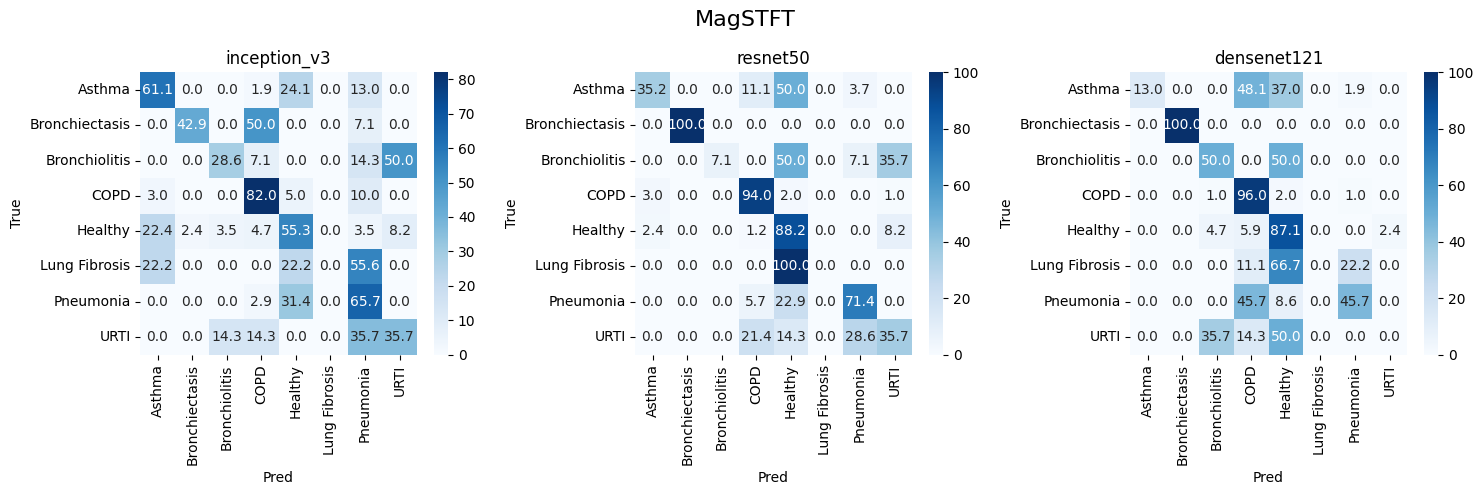

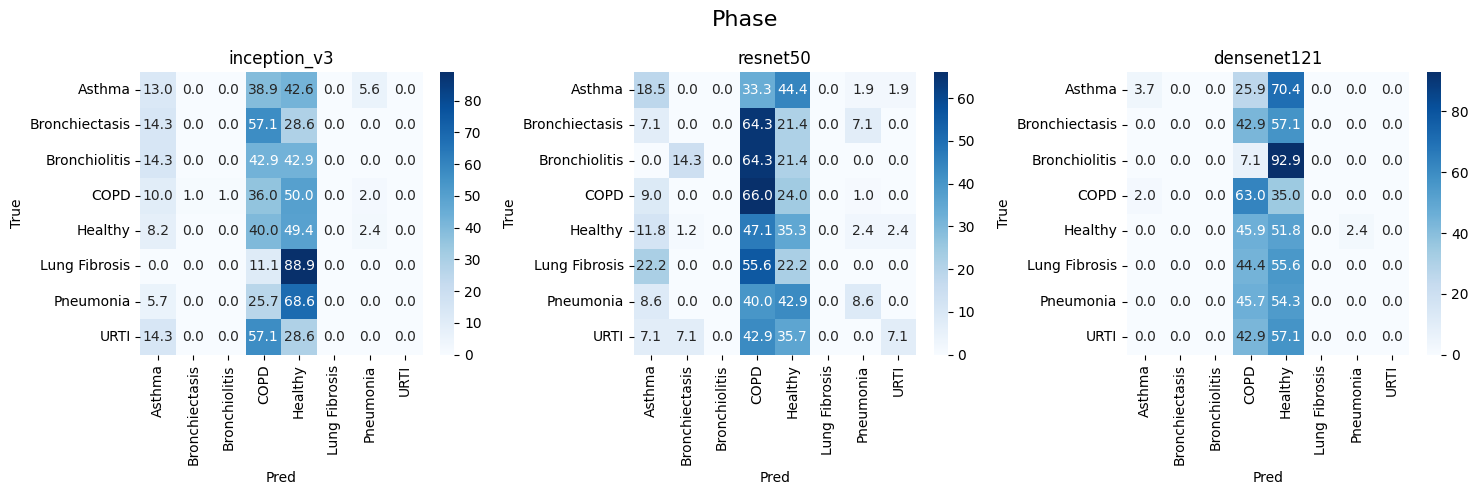

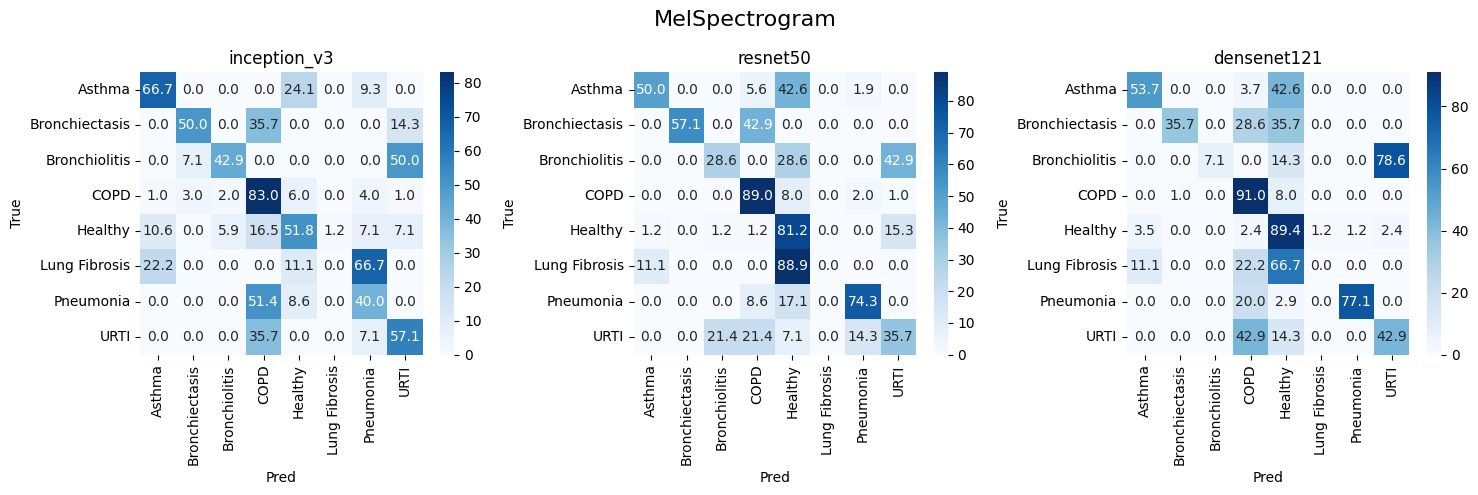

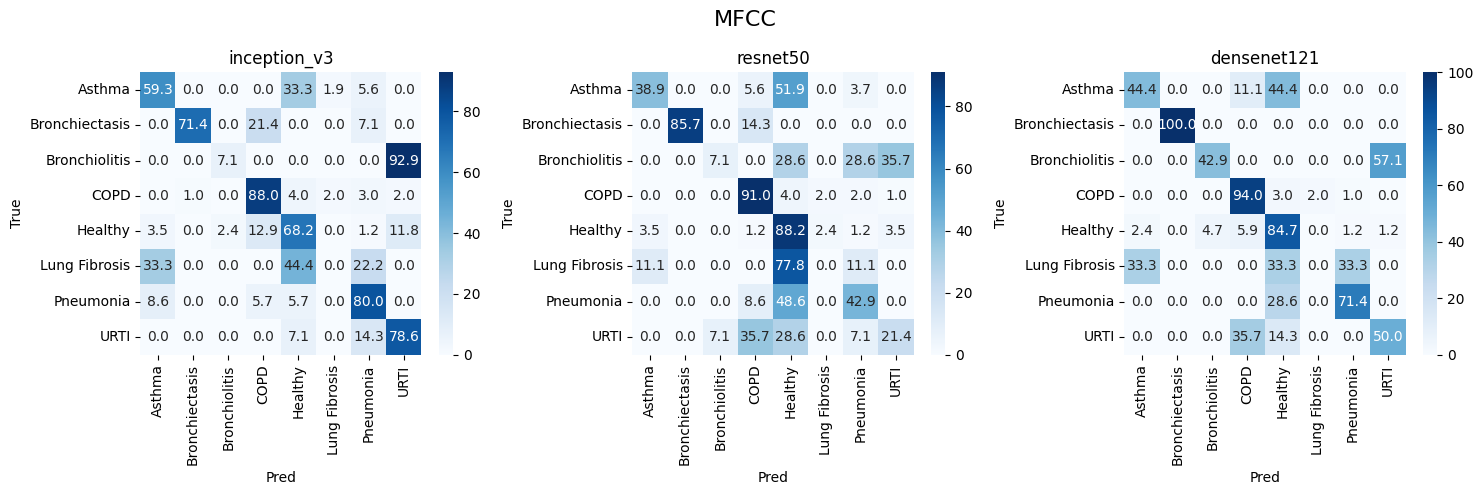

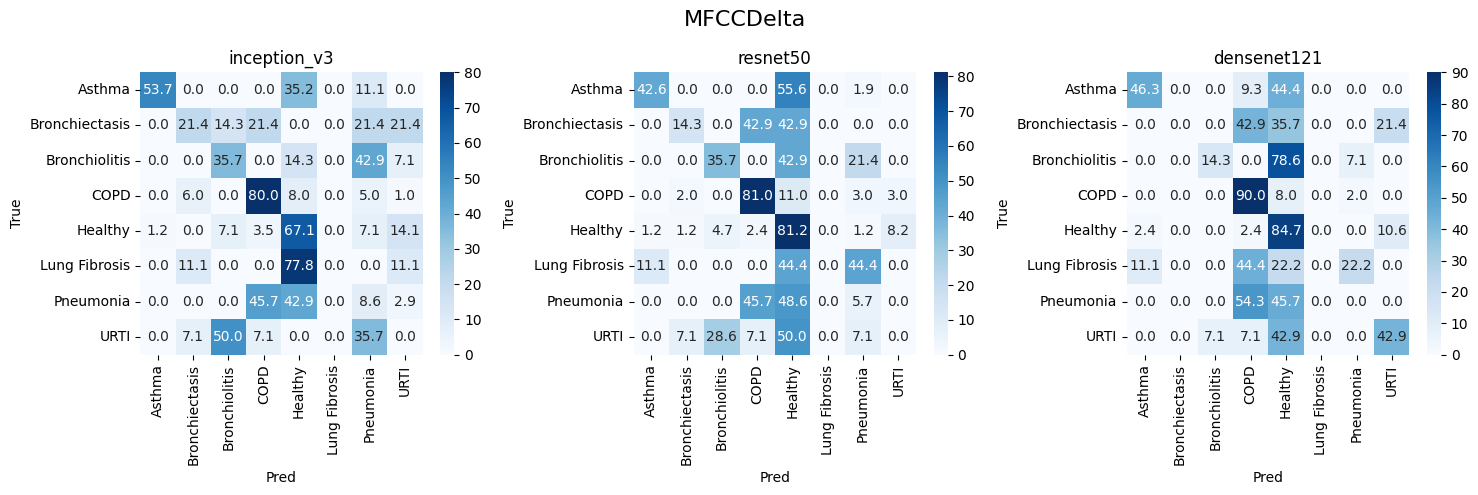

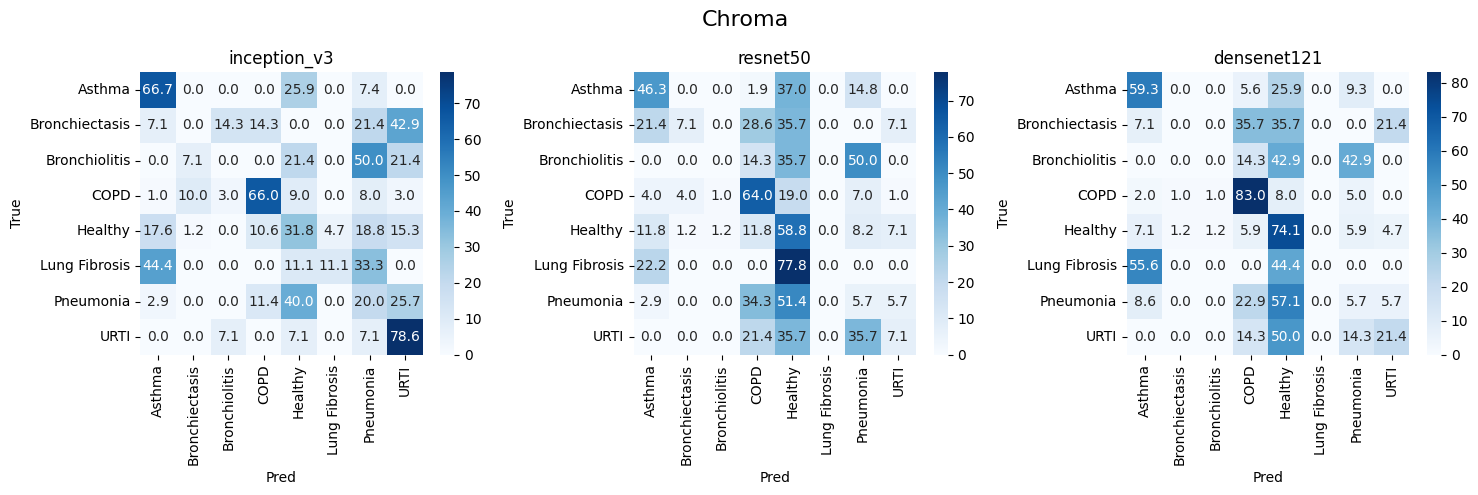

In [2]:
experiments = {
    "inception_v3 - MagSTFT": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "inception_v3 - Phase": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "inception_v3 - MelSpectrogram": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "inception_v3 - MFCC": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "inception_v3 - MFCCDelta": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "inception_v3 - Chroma": "../results/results_comparison/inception_v3-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "resnet50 - MagSTFT": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "resnet50 - Phase": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "resnet50 - MelSpectrogram": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "resnet50 - MFCC": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "resnet50 - MFCCDelta": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "resnet50 - Chroma": "../results/results_comparison/resnet50-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "densenet121 - MagSTFT": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - Phase": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "densenet121 - MelSpectrogram": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - MFCCDelta": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "densenet121 - Chroma": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
}

show_results(experiments)

# Comparing Features

======== Classification Reports ========


========== Confusion Matrices ==========


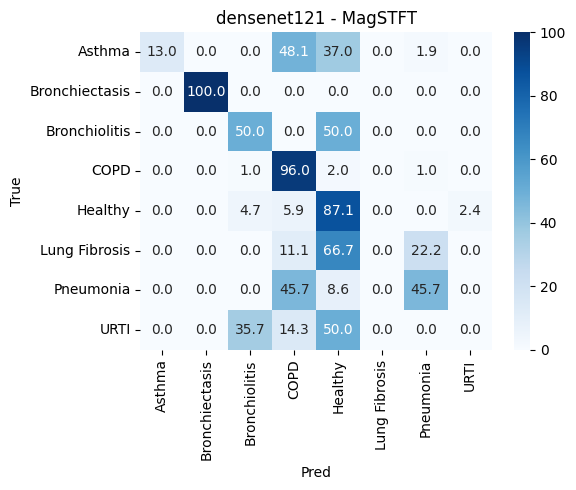

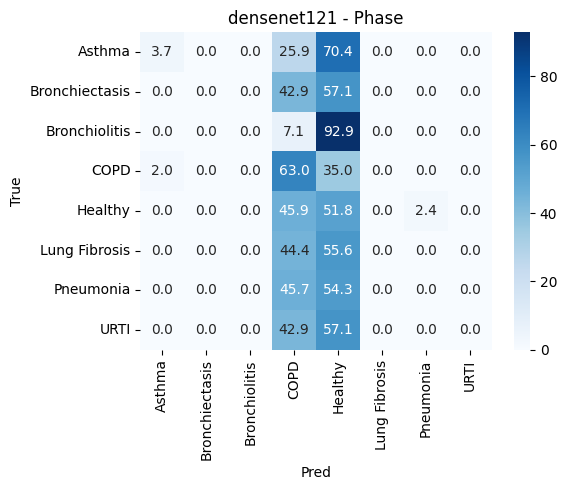

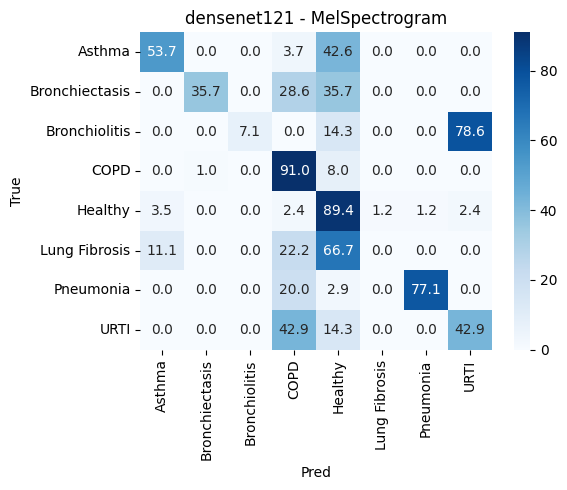

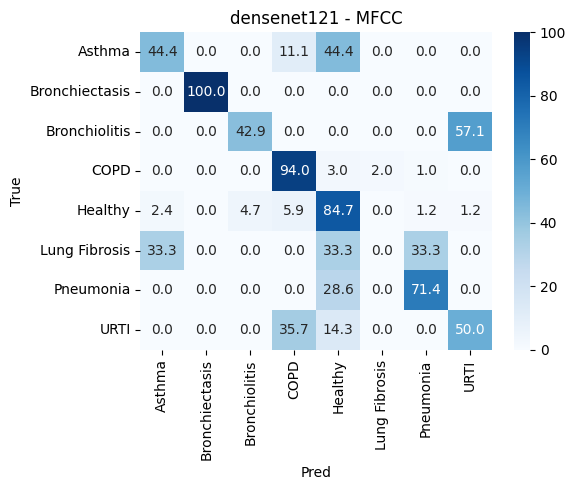

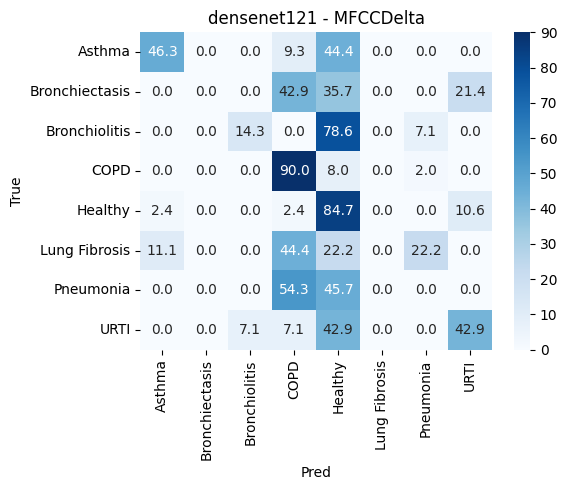

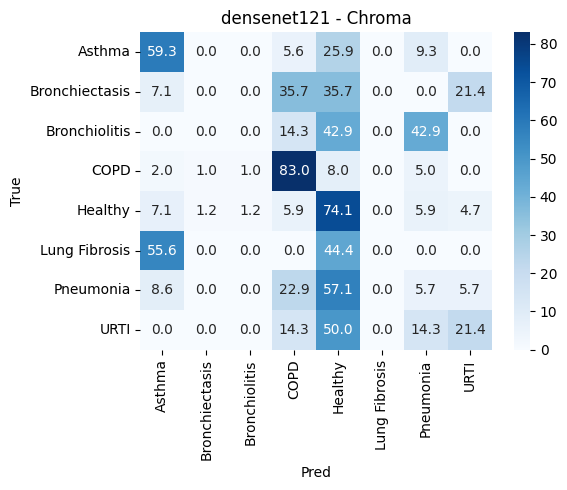

In [3]:
experiments = {
    "densenet121 - MagSTFT": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - Phase": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "densenet121 - MelSpectrogram": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - MFCCDelta": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "densenet121 - Chroma": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
}

show_results(experiments)

# Comparing Stacks

### The STFT

======== Classification Reports ========


========== Confusion Matrices ==========


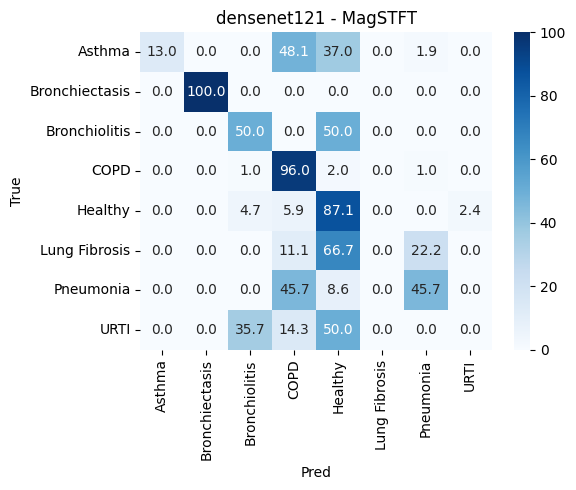

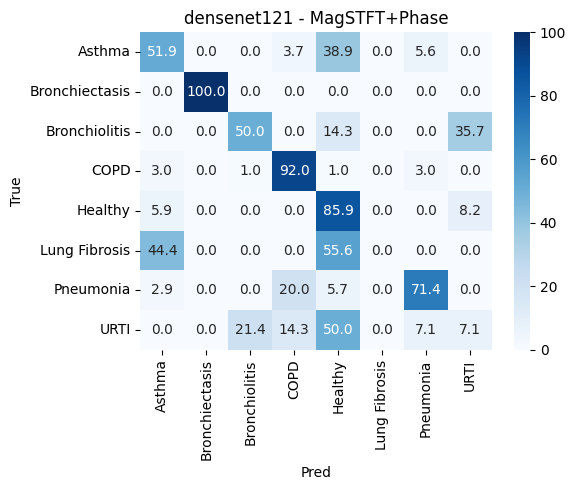

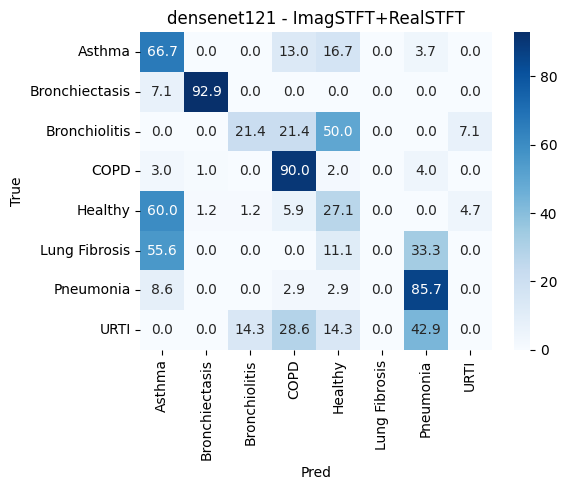

In [4]:
experiments = {
    "densenet121 - MagSTFT": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - MagSTFT+Phase": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Stack_MagSTFT_Phase_results.csv",
    "densenet121 - ImagSTFT+RealSTFT": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Stack_ImagSTFT_RealSTFT_results.csv",
}

show_results(experiments)

### MelSpectogram + MFCC + Chroma

======== Classification Reports ========


========== Confusion Matrices ==========


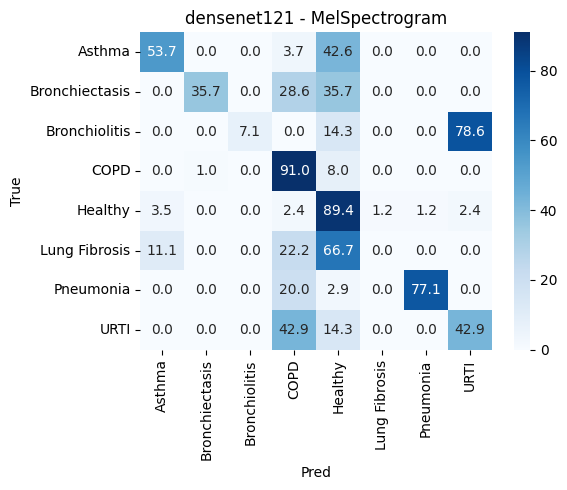

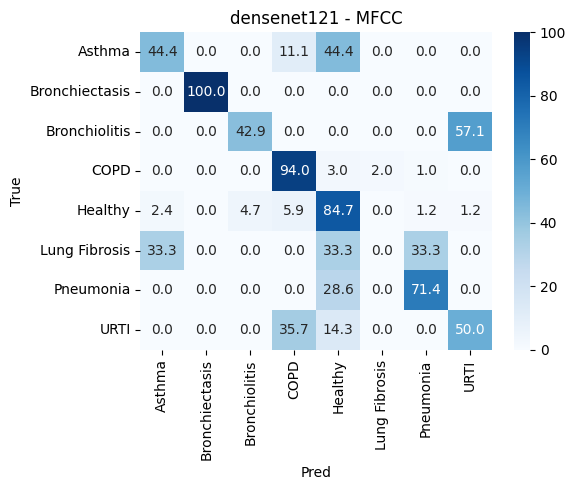

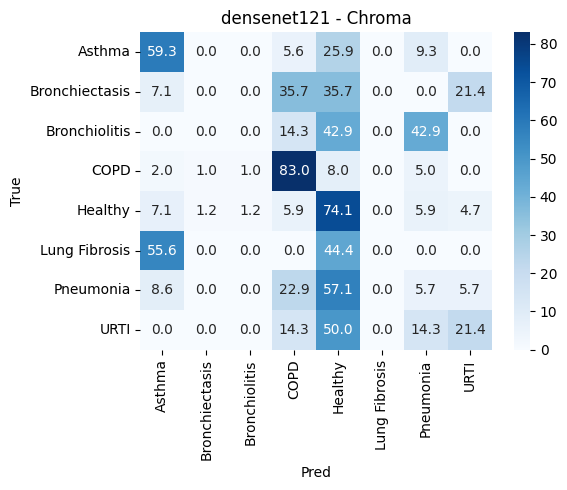

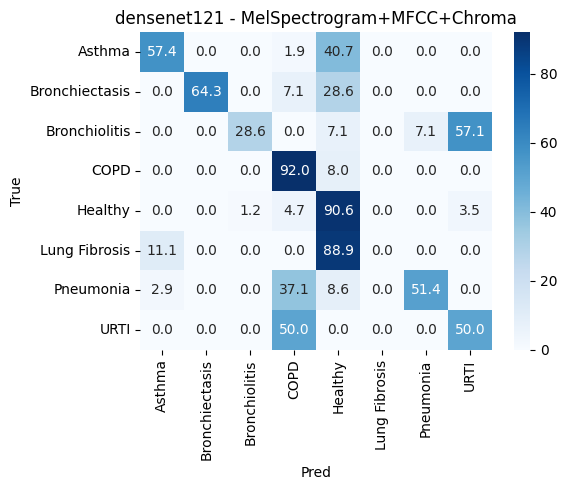

In [5]:
experiments = {
    "densenet121 - MelSpectrogram": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - Chroma": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "densenet121 - MelSpectrogram+MFCC+Chroma": "../results/results_comparison/densenet121-classes=8-equalizer-sample_limit=1000-Stack_MelSpectrogram_MFCC_Chroma_results.csv",
}

show_results(experiments)